# mHealth Dataset 기반 CNN+GRU 분류

## 결과 분석

CNN4 Test accuracy: 97.61%

CNN2 + GRU2 Test accuracy: 98.80%

CNN 단독 모델은 mHealth 데이터셋에서 97.61%의 높은 정확도를 보였으나 CNN+GRU 모델은 98.80%의 정확도를 기록하여 CNN 단독 모델 대비 1.19% 성능 향상을 보였다.

CNN이 센서 신호의 짧은 구간 local pattern을 효과적으로 추출한 뒤 GRU가 시간 순서에 따른 움직임 변화 정보를 추가로 학습했기 때문으로 판단된다.

특히 mHealth 데이터처럼 걷기, 뛰기와 같이 연속적인 움직임 흐름이 중요한 HAR 데이터에서는 GRU가 CNN feature의 temporal dependency를 보완하여 분류 성능 향상에 기여한 것으로 볼 수 있다.

다만 CNN만으로도 이미 높은 성능을 보였기 때문에 GRU의 효과는 CNN의 한계 temporal feature 보완에 따른 일부 향상으로 볼 수 있다.




In [18]:
# 라이브러리 import
from pathlib import Path

import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Input, Conv1D, GRU, BatchNormalization, ReLU, MaxPool1D,
    Dense, Dropout
)
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam

from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.utils import class_weight
from sklearn.metrics import classification_report, confusion_matrix

In [19]:
# 구글 드라이브 연결
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import os
import pandas as pd

# mHealth raw 데이터 로드
base_dir = "/content/drive/MyDrive"

FEATURE_COLUMNS = [f'sensor_{i+1}' for i in range(23)]
LABEL_COLUMN = 'label'
SUBJECT_COLUMN = 'subject'

LABELS = [
    'Standing still',
    'Sitting and relaxing',
    'Lying down',
    'Walking',
    'Climbing stairs',
    'Waist bends forward',
    'Frontal elevation of arms',
    'Knees bending',
    'Cycling',
    'Jogging',
    'Running',
    'Jump front and back'
]

dfs = []

for i in range(1, 11):
    path = os.path.join(base_dir, f"mHealth_subject{i}.log")
    df_i = pd.read_csv(path, sep=r"\s+", header=None)
    df_i.columns = FEATURE_COLUMNS + [LABEL_COLUMN]
    df_i[SUBJECT_COLUMN] = i
    dfs.append(df_i)

data = pd.concat(dfs, ignore_index=True)

## 데이터 전처리

1. **mHealth 로그 파일 로드**
2. **클린업**: 라벨 0 제거, 23개 센서 컬럼을 float32로 변환
3. **Label Encoding**: mHealth activity 이름을 정수 라벨로 변환
4. **Data Split (subject 기반)**:
  - subject 1~7: train
  - subject 8: validation
  - subject 9~10: test
5. **정규화**: StandardScaler를 train에서 fit, val/test는 transform만
6. **Segmentation**: sliding window (TIME_STEPS=200, STEP=40)


In [21]:
# 클린업
# 라벨 0은 비활동/전환 구간이므로 실제 12개 activity만 사용
df = data[data[LABEL_COLUMN] > 0].copy()

# 센서 값을 float32 숫자형으로 변환
for col in FEATURE_COLUMNS:
    df[col] = pd.to_numeric(df[col], errors='coerce').astype(np.float32)

df[LABEL_COLUMN] = df[LABEL_COLUMN].astype(np.int32)
df[SUBJECT_COLUMN] = df[SUBJECT_COLUMN].astype(np.int32)
df = df.dropna().reset_index(drop=True)

# 라벨 번호를 activity 이름으로 변환
df['activity'] = df[LABEL_COLUMN].map(lambda label: LABELS[label - 1])

In [22]:
# Label Encoding
label_encoder = LabelEncoder()
df['activity_encoded'] = label_encoder.fit_transform(df['activity'])
num_classes = len(label_encoder.classes_)
print()
print('Label mapping:', dict(enumerate(label_encoder.classes_)))


Label mapping: {0: 'Climbing stairs', 1: 'Cycling', 2: 'Frontal elevation of arms', 3: 'Jogging', 4: 'Jump front and back', 5: 'Knees bending', 6: 'Lying down', 7: 'Running', 8: 'Sitting and relaxing', 9: 'Standing still', 10: 'Waist bends forward', 11: 'Walking'}


In [23]:
# Data Split (subject 기반)
# subject 1~7 = train set
# subject 8 = validation set
# subject 9~10 = test set
TRAIN_SUBJECTS = list(range(1, 8))
VAL_SUBJECTS = [8]
TEST_SUBJECTS = [9, 10]

df_train = df[df[SUBJECT_COLUMN].isin(TRAIN_SUBJECTS)].copy()
df_val   = df[df[SUBJECT_COLUMN].isin(VAL_SUBJECTS)].copy()
df_test  = df[df[SUBJECT_COLUMN].isin(TEST_SUBJECTS)].copy()

In [24]:
# 정규화
scaler = StandardScaler()

df_train.loc[:, FEATURE_COLUMNS] = scaler.fit_transform(df_train.loc[:, FEATURE_COLUMNS])

if not df_val.empty:
    df_val.loc[:, FEATURE_COLUMNS] = scaler.transform(df_val.loc[:, FEATURE_COLUMNS])

if not df_test.empty:
    df_test.loc[:, FEATURE_COLUMNS] = scaler.transform(df_test.loc[:, FEATURE_COLUMNS])

In [25]:
# Segmentation (Sliding Window)
# 연속된 센서 데이터를 고정 길이 window로 분할
# subject와 activity segment 경계를 넘는 window가 생기지 않도록 그룹별로 생성
def create_dataset(df_split, time_steps=200, step=40):
    xs, ys = [], []

    if df_split.empty:
        return np.empty((0, time_steps, len(FEATURE_COLUMNS)), dtype=np.float32), np.empty((0,), dtype=np.int32)

    df_split = df_split.copy()
    segment_id = df_split.groupby(SUBJECT_COLUMN)['activity_encoded'].transform(lambda s: s.ne(s.shift()).cumsum())
    df_split['segment'] = segment_id

    for _, segment in df_split.groupby([SUBJECT_COLUMN, 'segment'], sort=False):
        x_values = segment[FEATURE_COLUMNS].to_numpy(dtype=np.float32)
        y_value = int(segment['activity_encoded'].iloc[0])

        for i in range(0, len(x_values) - time_steps + 1, step):
            xs.append(x_values[i:i + time_steps])
            ys.append(y_value)

    return np.array(xs, dtype=np.float32), np.array(ys, dtype=np.int32)


TIME_STEPS = 200
STEP = 40
x_train, y_train = create_dataset(df_train, TIME_STEPS, STEP)
x_val,   y_val   = create_dataset(df_val,   TIME_STEPS, STEP)
x_test,  y_test  = create_dataset(df_test,  TIME_STEPS, STEP)

print()
print(f'x_train: {x_train.shape}, y_train: {y_train.shape}')
print(f'x_val  : {x_val.shape},  y_val  : {y_val.shape}')
print(f'x_test : {x_test.shape},  y_test : {y_test.shape}')
print('train label distribution:', np.bincount(y_train, minlength=num_classes))
print('val label distribution:', np.bincount(y_val, minlength=num_classes))
print('test label distribution:', np.bincount(y_test, minlength=num_classes))


x_train: (5650, 200, 23), y_train: (5650,)
x_val  : (777, 200, 23),  y_val  : (777,)
x_test : (1588, 200, 23),  y_test : (1588,)
train label distribution: [504 504 488 504 148 492 504 504 504 504 490 504]
val label distribution: [72 72 71 72 21 60 72 72 72 72 49 72]
test label distribution: [144 144 132 144  43 137 144 144 144 144 124 144]


In [26]:
# 클래스 가중치 (불균형 보정)
# 모델이 적은 class도 무시하지 않도록
classes = np.unique(y_train)
weights = class_weight.compute_class_weight('balanced', classes=classes, y=y_train)
class_weights_dict = dict(zip(classes, weights))
print('Class weights:', class_weights_dict)

Class weights: {np.int32(0): np.float64(0.9341931216931217), np.int32(1): np.float64(0.9341931216931217), np.int32(2): np.float64(0.9648224043715847), np.int32(3): np.float64(0.9341931216931217), np.int32(4): np.float64(3.1813063063063063), np.int32(5): np.float64(0.9569783197831978), np.int32(6): np.float64(0.9341931216931217), np.int32(7): np.float64(0.9341931216931217), np.int32(8): np.float64(0.9341931216931217), np.int32(9): np.float64(0.9341931216931217), np.int32(10): np.float64(0.9608843537414966), np.int32(11): np.float64(0.9341931216931217)}


## Model 1
- CNN 2 (Conv1D 2개) + GRU 1

In [27]:
input_shape = (x_train.shape[1], x_train.shape[2])
num_classes = len(label_encoder.classes_)

model1 = Sequential()
model1.add(Input(shape=input_shape))

model1.add(Conv1D(filters=64, kernel_size=3, padding="same"))
model1.add(BatchNormalization())
model1.add(ReLU())
model1.add(MaxPool1D(2))
model1.add(Dropout(0.2))

model1.add(Conv1D(filters=128, kernel_size=3, padding="same"))
model1.add(BatchNormalization())
model1.add(ReLU())

model1.add(GRU(128, dropout=0.2, recurrent_dropout=0.0))

model1.add(Dense(128, activation='relu'))
model1.add(Dropout(0.4))
model1.add(Dense(num_classes, activation='softmax'))

model1.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['sparse_categorical_accuracy']
)

print(model1.summary())

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_4 (Conv1D)               │ (None, 200, 64)        │         4,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 200, 64)        │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_4 (ReLU)                  │ (None, 200, 64)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_2 (MaxPooling1D)  │ (None, 100, 64)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 100, 64)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_5 (Conv1D)               │ (None, 100, 128)       │        24,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 100, 128)       │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_5 (ReLU)                  │ (None, 100, 128)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_3 (GRU)                     │ (None, 128)            │        99,072 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 12)             │         1,548 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 147,084 (574.55 KB)

 Trainable params: 146,700 (573.05 KB)

 Non-trainable params: 384 (1.50 KB)

None


In [28]:
callbacks1 = [
    ModelCheckpoint(
        'mHealth_CNN2_GRU1_best.h5',
        save_best_only=True,
        monitor='val_loss',
        mode='max',
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=5,
        min_lr=1e-6,
        verbose=1
    ),
    EarlyStopping(
        monitor='val_loss',
        patience=20,
        verbose=1,
        mode='max',
        restore_best_weights=True
    )
]

history1 = model1.fit(
    x_train, y_train,
    epochs=100,
    batch_size=32,
    validation_data=(x_val, y_val),
    callbacks=callbacks1,
    class_weight=class_weights_dict,
    verbose=1
)

Epoch 1/100
177/177 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 1.4241 - sparse_categorical_accuracy: 0.5205
Epoch 1: val_loss improved from None to 0.35328, saving model to mHealth_CNN2_GRU1_best.h5



Epoch 1: finished saving model to mHealth_CNN2_GRU1_best.h5
177/177 ━━━━━━━━━━━━━━━━━━━━ 7s 19ms/step - loss: 0.8499 - sparse_categorical_accuracy: 0.7101 - val_loss: 0.3533 - val_sparse_categorical_accuracy: 0.8494 - learning_rate: 0.0010
Epoch 2/100
174/177 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.1210 - sparse_categorical_accuracy: 0.9570
Epoch 2: val_loss did not improve from 0.35328
177/177 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - loss: 0.1007 - sparse_categorical_accuracy: 0.9634 - val_loss: 0.0581 - val_sparse_categorical_accuracy: 0.9781 - learning_rate: 0.0010
Epoch 3/100
177/177 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0493 - sparse_categorical_accuracy: 0.9832
Epoch 3: val_loss did not improve from 0.35328
177/177 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - loss: 0.0466 - sparse_categorical_accuracy: 0.9839 - val_loss: 0.0190 - val_sparse_categorical_accuracy: 0.9987 - learning_rate: 0.0010
Epoch 4/100
174/177 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0271 - sparse_categorical_a


Epoch 6: finished saving model to mHealth_CNN2_GRU1_best.h5
177/177 ━━━━━━━━━━━━━━━━━━━━ 3s 19ms/step - loss: 0.0204 - sparse_categorical_accuracy: 0.9947 - val_loss: 0.6246 - val_sparse_categorical_accuracy: 0.8610 - learning_rate: 0.0010
Epoch 7/100
173/177 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0064 - sparse_categorical_accuracy: 0.9983
Epoch 7: val_loss improved from 0.62464 to 0.64889, saving model to mHealth_CNN2_GRU1_best.h5



Epoch 7: finished saving model to mHealth_CNN2_GRU1_best.h5
177/177 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - loss: 0.0067 - sparse_categorical_accuracy: 0.9981 - val_loss: 0.6489 - val_sparse_categorical_accuracy: 0.8880 - learning_rate: 0.0010
Epoch 8/100
174/177 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0338 - sparse_categorical_accuracy: 0.9931
Epoch 8: val_loss did not improve from 0.64889

Epoch 8: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
177/177 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - loss: 0.0201 - sparse_categorical_accuracy: 0.9958 - val_loss: 0.1375 - val_sparse_categorical_accuracy: 0.9447 - learning_rate: 0.0010
Epoch 9/100
173/177 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0020 - sparse_categorical_accuracy: 0.9999
Epoch 9: val_loss did not improve from 0.64889
177/177 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - loss: 0.0022 - sparse_categorical_accuracy: 0.9998 - val_loss: 0.0606 - val_sparse_categorical_accuracy: 0.9833 - learning_rate: 5.0000e-04
Epoch 10/1

In [29]:
# 모델 평가
model1 = tf.keras.models.load_model('mHealth_CNN2_GRU1_best.h5')

train_loss, train_acc = model1.evaluate(x_train, y_train, verbose=0)
print(f'Training accuracy: {train_acc * 100:.2f}%')
print(f'Training loss: {train_loss:.4f}')

test_loss, test_acc = model1.evaluate(x_test, y_test, verbose=0)
print(f'Test accuracy: {test_acc * 100:.2f}%')
print(f'Test loss: {test_loss:.4f}')

Training accuracy: 99.91%
Training loss: 0.0013
Test accuracy: 95.47%
Test loss: 0.1541


In [30]:
y_pred_proba = model1.predict(x_test, verbose=0)
y_pred = np.argmax(y_pred_proba, axis=1)

print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=label_encoder.classes_, digits=4))


Classification Report:
                           precision    recall  f1-score   support

          Climbing stairs     1.0000    1.0000    1.0000       144
                  Cycling     1.0000    1.0000    1.0000       144
Frontal elevation of arms     0.6471    1.0000    0.7857       132
                  Jogging     1.0000    1.0000    1.0000       144
      Jump front and back     1.0000    1.0000    1.0000        43
            Knees bending     1.0000    1.0000    1.0000       137
               Lying down     1.0000    1.0000    1.0000       144
                  Running     1.0000    1.0000    1.0000       144
     Sitting and relaxing     1.0000    0.5000    0.6667       144
           Standing still     1.0000    1.0000    1.0000       144
      Waist bends forward     1.0000    1.0000    1.0000       124
                  Walking     1.0000    1.0000    1.0000       144

                 accuracy                         0.9547      1588
                macro avg     0.9706

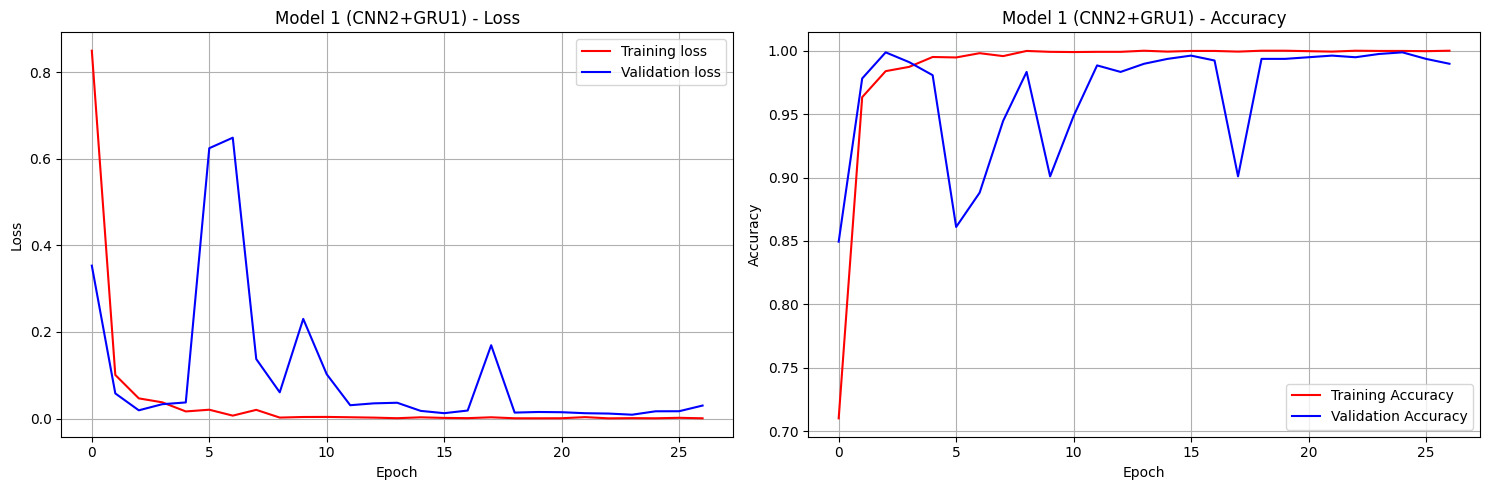

In [31]:
train_loss_h1 = history1.history['loss']
train_accuracy_h1 = history1.history['sparse_categorical_accuracy']
val_loss_h1 = history1.history['val_loss']
val_accuracy_h1 = history1.history['val_sparse_categorical_accuracy']

plt.figure(figsize=(15, 5))

plt.subplot(1, 2, 1)
plt.plot(train_loss_h1, 'r', label='Training loss')
plt.plot(val_loss_h1, 'b', label='Validation loss')
plt.title('Model 1 (CNN2+GRU1) - Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(train_accuracy_h1, 'r', label='Training Accuracy')
plt.plot(val_accuracy_h1, 'b', label='Validation Accuracy')
plt.title('Model 1 (CNN2+GRU1) - Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

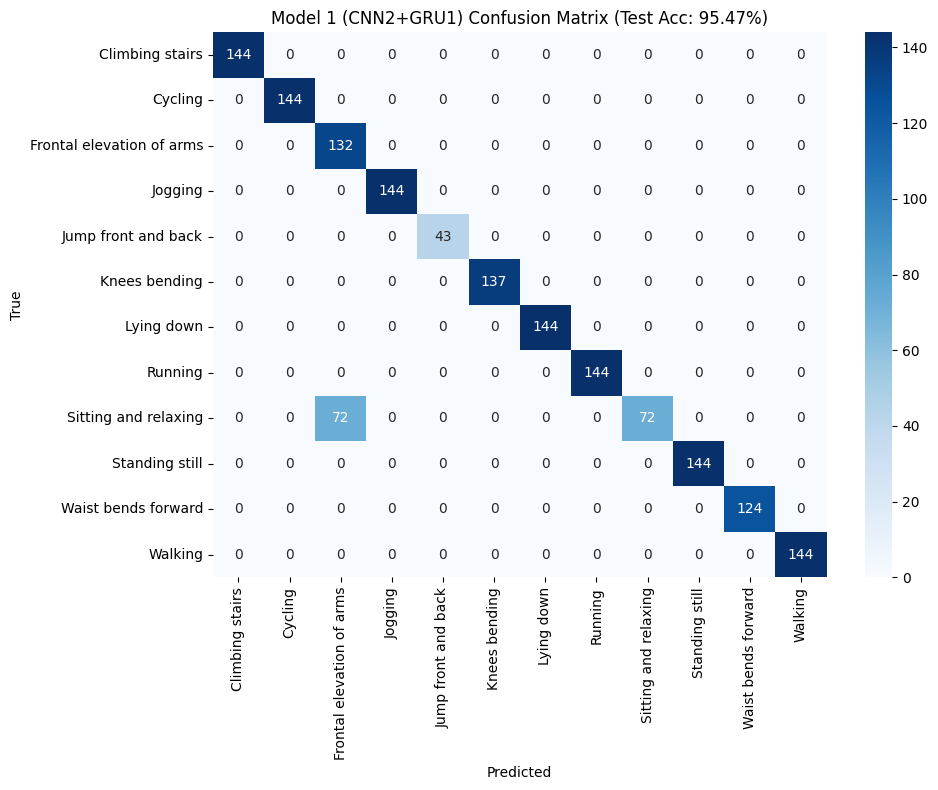

In [32]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=label_encoder.classes_, yticklabels=label_encoder.classes_)
plt.title(f'Model 1 (CNN2+GRU1) Confusion Matrix (Test Acc: {test_acc * 100:.2f}%)')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.tight_layout()
plt.show()

## Model 2
- CNN 2 (Conv1D 2개) + GRU 2

In [33]:
model2 = Sequential()
model2.add(Input(shape=input_shape))

model2.add(Conv1D(filters=64, kernel_size=3, padding="same"))
model2.add(BatchNormalization())
model2.add(ReLU())
model2.add(MaxPool1D(2))

model2.add(Conv1D(filters=128, kernel_size=3, padding="same"))
model2.add(BatchNormalization())
model2.add(ReLU())

model2.add(GRU(64, return_sequences=True, dropout=0.2, recurrent_dropout=0.0))
model2.add(GRU(64, return_sequences=False, dropout=0.2, recurrent_dropout=0.0))

model2.add(Dense(units=64, activation='relu'))
model2.add(Dropout(0.3))
model2.add(Dense(num_classes, activation='softmax'))

model2.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['sparse_categorical_accuracy']
)

print(model2.summary())

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_6 (Conv1D)               │ (None, 200, 64)        │         4,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 200, 64)        │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_6 (ReLU)                  │ (None, 200, 64)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_3 (MaxPooling1D)  │ (None, 100, 64)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_7 (Conv1D)               │ (None, 100, 128)       │        24,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 100, 128)       │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_7 (ReLU)                  │ (None, 100, 128)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_4 (GRU)                     │ (None, 100, 64)        │        37,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_5 (GRU)                     │ (None, 64)             │        24,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 12)             │           780 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 97,100 (379.30 KB)

 Trainable params: 96,716 (377.80 KB)

 Non-trainable params: 384 (1.50 KB)

None


In [34]:
callbacks2 = [
    ModelCheckpoint(
        'mHealth_CNN2_GRU2_best.h5',
        save_best_only=True,
        monitor='val_loss',
        mode='max',
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=5,
        min_lr=1e-6,
        verbose=1
    ),
    EarlyStopping(
        monitor='val_loss',
        patience=20,
        verbose=1,
        mode='max',
        restore_best_weights=True
    )
]

history2 = model2.fit(
    x_train, y_train,
    epochs=100,
    batch_size=32,
    validation_data=(x_val, y_val),
    callbacks=callbacks2,
    class_weight=class_weights_dict,
    verbose=1
)

Epoch 1/100
177/177 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 1.5725 - sparse_categorical_accuracy: 0.5070
Epoch 1: val_loss improved from None to 0.42105, saving model to mHealth_CNN2_GRU2_best.h5



Epoch 1: finished saving model to mHealth_CNN2_GRU2_best.h5
177/177 ━━━━━━━━━━━━━━━━━━━━ 7s 21ms/step - loss: 0.9604 - sparse_categorical_accuracy: 0.6945 - val_loss: 0.4210 - val_sparse_categorical_accuracy: 0.8584 - learning_rate: 0.0010
Epoch 2/100
177/177 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 0.1374 - sparse_categorical_accuracy: 0.9614
Epoch 2: val_loss did not improve from 0.42105
177/177 ━━━━━━━━━━━━━━━━━━━━ 4s 23ms/step - loss: 0.0979 - sparse_categorical_accuracy: 0.9754 - val_loss: 0.2421 - val_sparse_categorical_accuracy: 0.9073 - learning_rate: 0.0010
Epoch 3/100
175/177 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0580 - sparse_categorical_accuracy: 0.9881
Epoch 3: val_loss did not improve from 0.42105
177/177 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step - loss: 0.0438 - sparse_categorical_accuracy: 0.9897 - val_loss: 0.1880 - val_sparse_categorical_accuracy: 0.9035 - learning_rate: 0.0010
Epoch 4/100
177/177 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0404 - sparse_categorical_a


Epoch 6: finished saving model to mHealth_CNN2_GRU2_best.h5
177/177 ━━━━━━━━━━━━━━━━━━━━ 3s 18ms/step - loss: 0.0210 - sparse_categorical_accuracy: 0.9949 - val_loss: 0.5863 - val_sparse_categorical_accuracy: 0.9138 - learning_rate: 0.0010
Epoch 7/100
177/177 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.0219 - sparse_categorical_accuracy: 0.9932
Epoch 7: val_loss did not improve from 0.58627
177/177 ━━━━━━━━━━━━━━━━━━━━ 3s 20ms/step - loss: 0.0152 - sparse_categorical_accuracy: 0.9958 - val_loss: 0.1273 - val_sparse_categorical_accuracy: 0.9678 - learning_rate: 0.0010
Epoch 8/100
176/177 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0038 - sparse_categorical_accuracy: 0.9996
Epoch 8: val_loss did not improve from 0.58627
177/177 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step - loss: 0.0036 - sparse_categorical_accuracy: 0.9995 - val_loss: 0.1069 - val_sparse_categorical_accuracy: 0.9678 - learning_rate: 0.0010
Epoch 9/100
177/177 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0041 - sparse_categorical_a

In [35]:
# 모델 평가
model2 = tf.keras.models.load_model('mHealth_CNN2_GRU2_best.h5')

train_loss2, train_acc2 = model2.evaluate(x_train, y_train, verbose=0)
print(f'Training accuracy: {train_acc2 * 100:.2f}%')
print(f'Training loss: {train_loss2:.4f}')

test_loss2, test_acc2 = model2.evaluate(x_test, y_test, verbose=0)
print(f'Test accuracy: {test_acc2 * 100:.2f}%')
print(f'Test loss: {test_loss2:.4f}')

Training accuracy: 100.00%
Training loss: 0.0007
Test accuracy: 98.80%
Test loss: 0.0501


In [36]:
y_pred_proba2 = model2.predict(x_test, verbose=0)
y_pred2 = np.argmax(y_pred_proba2, axis=1)

print("\nClassification Report:")
print(classification_report(y_test, y_pred2, target_names=label_encoder.classes_, digits=4))


Classification Report:
                           precision    recall  f1-score   support

          Climbing stairs     0.8834    1.0000    0.9381       144
                  Cycling     1.0000    1.0000    1.0000       144
Frontal elevation of arms     1.0000    1.0000    1.0000       132
                  Jogging     1.0000    1.0000    1.0000       144
      Jump front and back     1.0000    1.0000    1.0000        43
            Knees bending     1.0000    1.0000    1.0000       137
               Lying down     1.0000    1.0000    1.0000       144
                  Running     1.0000    1.0000    1.0000       144
     Sitting and relaxing     1.0000    1.0000    1.0000       144
           Standing still     1.0000    1.0000    1.0000       144
      Waist bends forward     1.0000    1.0000    1.0000       124
                  Walking     1.0000    0.8681    0.9294       144

                 accuracy                         0.9880      1588
                macro avg     0.9903

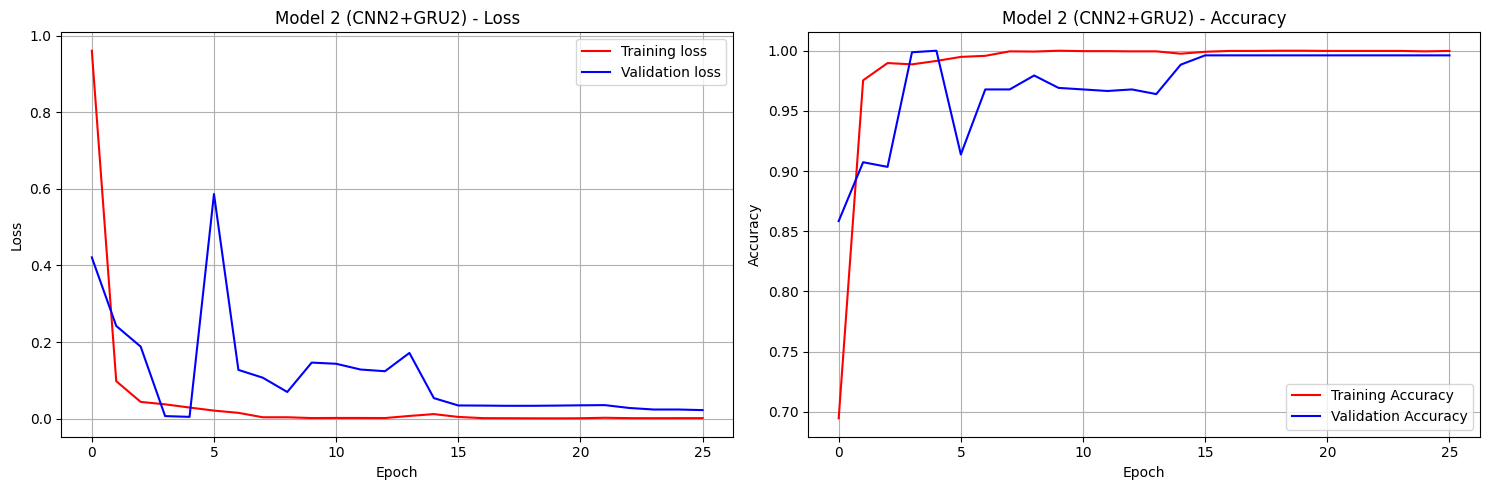

In [37]:
train_loss_h2 = history2.history['loss']
train_accuracy_h2 = history2.history['sparse_categorical_accuracy']
val_loss_h2 = history2.history['val_loss']
val_accuracy_h2 = history2.history['val_sparse_categorical_accuracy']

plt.figure(figsize=(15, 5))

plt.subplot(1, 2, 1)
plt.plot(train_loss_h2, 'r', label='Training loss')
plt.plot(val_loss_h2, 'b', label='Validation loss')
plt.title('Model 2 (CNN2+GRU2) - Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(train_accuracy_h2, 'r', label='Training Accuracy')
plt.plot(val_accuracy_h2, 'b', label='Validation Accuracy')
plt.title('Model 2 (CNN2+GRU2) - Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

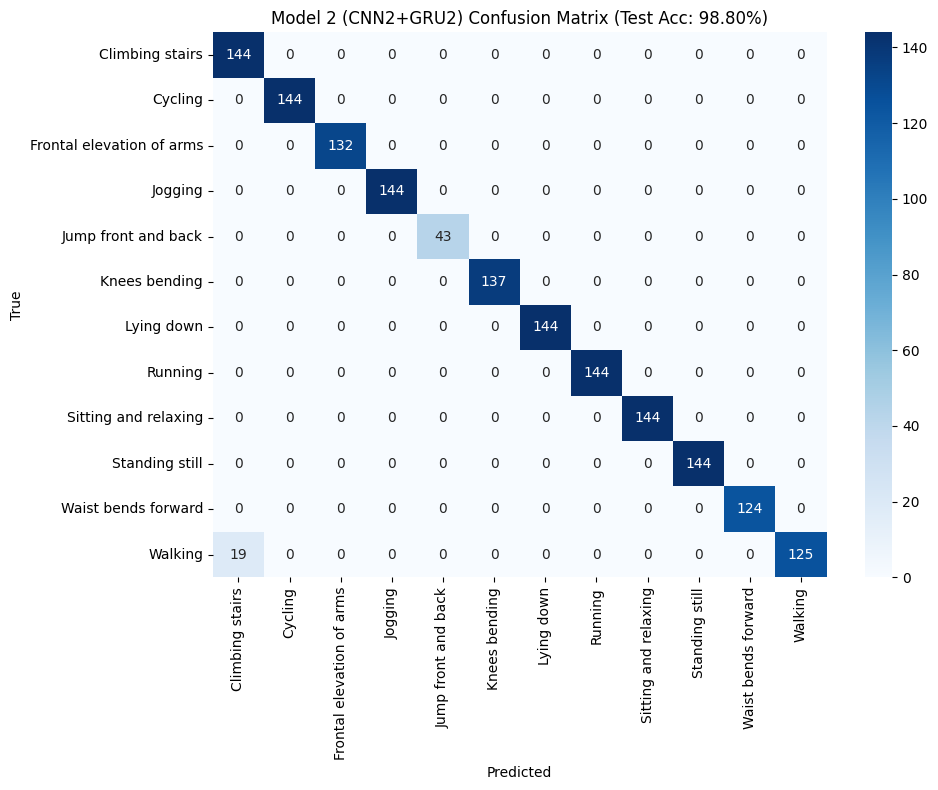

In [38]:
cm2 = confusion_matrix(y_test, y_pred2)

plt.figure(figsize=(10, 8))
sns.heatmap(cm2, annot=True, fmt='d', cmap='Blues',
            xticklabels=label_encoder.classes_, yticklabels=label_encoder.classes_)
plt.title(f'Model 2 (CNN2+GRU2) Confusion Matrix (Test Acc: {test_acc2 * 100:.2f}%)')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.tight_layout()
plt.show()